# STA 141A: Predicting Wildfire Incidence in the United States
## Hoang Trang Thy Trinh ##

### Abstract


### 1. Data Preprocessing

This section should clearly explain how the raw wildfire data are transformed into the final dataset used for modeling.

The report should explain
- How notable fires are identified and filtered  
- How space–time units are constructed (e.g., grid-by-month)  
- How the binary outcome variable is defined  
- How predictors are constructed or aggregated  
- How missing data or edge cases are handled  

**Minimum required output:** A summary table describing the final dataset used for predictive modeling. 

In [331]:
install.packages("e1071")
install.packages("neuralnet")
install.packages("caret")


The downloaded binary packages are in
	/var/folders/j8/qjq_kk4n1lzcfy_4x49w9lc40000gn/T//RtmpuD5FiD/downloaded_packages

The downloaded binary packages are in
	/var/folders/j8/qjq_kk4n1lzcfy_4x49w9lc40000gn/T//RtmpuD5FiD/downloaded_packages


also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘recipes’, ‘reshape2’





The downloaded binary packages are in
	/var/folders/j8/qjq_kk4n1lzcfy_4x49w9lc40000gn/T//RtmpuD5FiD/downloaded_packages


In [332]:
suppressPackageStartupMessages({
    library(dplyr)
    library(ggplot2)
    library(tidyverse)
    library(pROC)
    library(Matrix)
    library(usmap)
    library(rpart)
    library(rpart.plot)
    library(randomForest)
    library(e1071)
    library(caret)
})

In [8]:
wildfires <-read.csv(file = "/Users/thytrinh/Desktop/STA141AW26/Data/wildfires_sample_100k.csv")
head(wildfires)
#glimpse(wildfires)

,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,⋯,FIRE_SIZE_CLASS,LATITUDE,LONGITUDE,OWNER_CODE,OWNER_DESCR,STATE,COUNTY,FIPS_CODE,FIPS_NAME,Shape
,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<dbl>,<dbl>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>
1,16,16,FS-1418876,FED,FS-FIRESTAT,FS,USCAENF,Eldorado National Forest,0503,Eldorado National Forest,⋯,A,38.56417,-120.5422,5,USFS,CA,17,17,El Dorado,<raw>
2,68,68,FS-1419017,FED,FS-FIRESTAT,FS,USMTKNF,Kootenai National Forest,0114,Kootenai National Forest,⋯,A,48.40778,-115.5578,13,STATE OR PRIVATE,MT,53,53,Lincoln,<raw>
3,73,74,FS-1419045,FED,FS-FIRESTAT,FS,USMTKNF,Kootenai National Forest,0114,Kootenai National Forest,⋯,B,48.89444,-115.1653,13,STATE OR PRIVATE,MT,53,53,Lincoln,<raw>
4,111,112,FS-1419134,FED,FS-FIRESTAT,FS,USCASNF,Sierra National Forest,0515,Sierra National Forest,⋯,A,37.04417,-119.3439,13,STATE OR PRIVATE,CA,NA,NA,NA,<raw>
5,191,194,FS-1419315,FED,FS-FIRESTAT,FS,USNMCAF,Carson National Forest,0302,Carson National Forest,⋯,A,36.90000,-107.3281,5,USFS,NM,39,39,Rio Arriba,<raw>
6,228,231,FS-1419384,FED,FS-FIRESTAT,FS,USAZASF,Apache-Sitgreaves National Forest,0301,Apache-Sitgreaves National Forest,⋯,A,33.66000,-109.3550,5,USFS,AZ,11,11,Greenlee,<raw>


In [357]:
wildfires_300 <- wildfires |> #Only keep rows with FIRE_SIZE >= 300
    filter(FIRE_SIZE >= 300) |>
    select(FIRE_YEAR, DISCOVERY_DOY, FIRE_SIZE, LATITUDE, LONGITUDE, STATE) |>
    mutate(STATE = as.factor(STATE))

glimpse(wildfires_300)

Rows: 1,381
Columns: 6
$ FIRE_YEAR     <int> 2005, 2005, 2005, 2005, 2005, 2005, 2005, 2005, 2005, 20…
$ DISCOVERY_DOY <int> 197, 198, 219, 217, 224, 246, 178, 257, 173, 57, 108, 11…
$ FIRE_SIZE     <dbl> 1300, 495, 800, 817, 600, 1132, 1315, 1419, 3000, 332, 3…
$ LATITUDE      <dbl> 33.93361, 33.86250, 48.83417, 45.97667, 45.74833, 43.820…
$ LONGITUDE     <dbl> -111.37972, -111.15583, -115.18500, -114.96000, -115.165…
$ STATE         <fct> AZ, AZ, MT, ID, ID, ID, AZ, OR, AZ, KY, OK, AZ, AZ, CA, …


In [9]:
sum(is.na(wildfires_300))

[1] 0

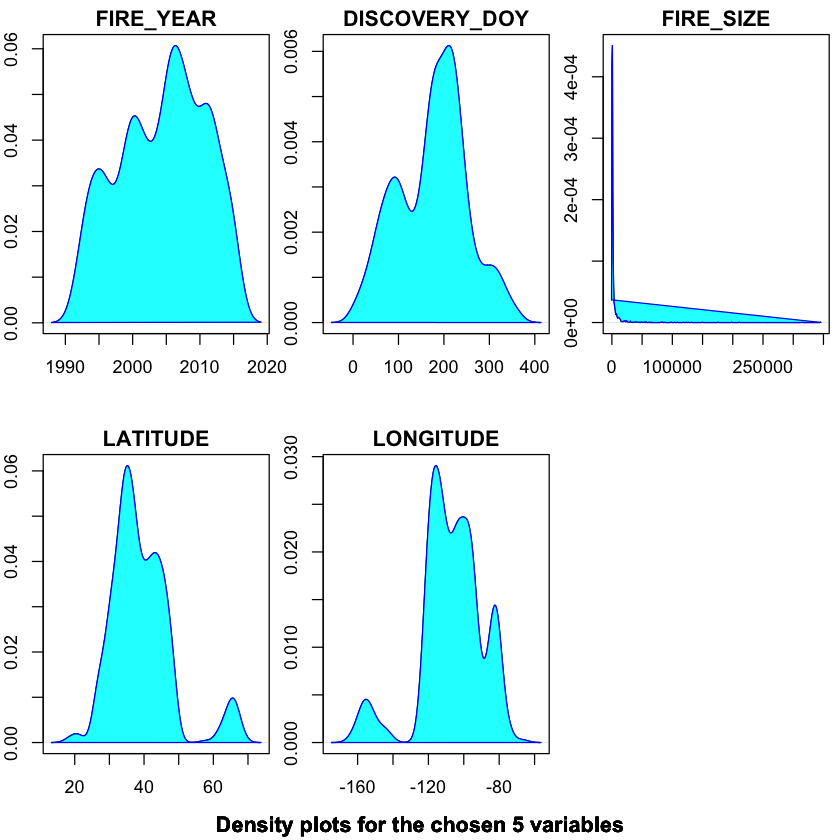

In [361]:
par(mfrow=c(2,3),mar=c(4, 2, 1.6, 0.5), cex = 0.9)

for (variables in 1:(dim(wildfires_300)[2]-1)){
  thisvar = wildfires_300[,variables]
  d <- density(thisvar)
  plot(d, main = names(wildfires_300[variables]),xlab="")
  polygon(d, col="cyan", border="blue")
  title("Density plots for the chosen 5 variables",line = -38.5, outer = TRUE)} 

`FIRE_SIZE` shows a heavy right skew even after filtering out values smaller than 300 acres. This is due rare and large fires that burn in the 200,000 acres. However, this is an appropriate cut-off, as the data entries are now roughly 1300, which is already roughly 87% decrease.

### Temporal Pattern

In [347]:
wildfires_300 <- wildfires_300 %>% 
    mutate(FIRE_DATE = as.Date(paste(FIRE_YEAR, DISCOVERY_DOY, sep = "-"), format = "%Y-%j"),
          YEAR = year(FIRE_DATE),
          MONTH = month(FIRE_DATE))

#head(wildfires_300)

### Spatial Pattern

In [348]:
wildfires_300 <- wildfires_300 %>%
  mutate(
    lat_bin = floor(LATITUDE),
    lon_bin = floor(LONGITUDE),
    ym = YEAR * 100 + MONTH   # e.g., 201507
  )

head(wildfires_300)

,FIRE_YEAR,DISCOVERY_DOY,FIRE_SIZE,LATITUDE,LONGITUDE,STATE,FIRE_DATE,YEAR,MONTH,lat_bin,lon_bin,ym
,<int>,<int>,<dbl>,<dbl>,<dbl>,<fct>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2005,197,1300,33.93361,-111.3797,AZ,2005-07-16,2005,7,33,-112,200507
2,2005,198,495,33.86250,-111.1558,AZ,2005-07-17,2005,7,33,-112,200507
3,2005,219,800,48.83417,-115.1850,MT,2005-08-07,2005,8,48,-116,200508
4,2005,217,817,45.97667,-114.9600,ID,2005-08-05,2005,8,45,-115,200508
5,2005,224,600,45.74833,-115.1650,ID,2005-08-12,2005,8,45,-116,200508
6,2005,246,1132,43.82056,-115.8956,ID,2005-09-03,2005,9,43,-116,200509


We are creating a grid-month panel from the filtered fire data `wildfires_300`. Since we are retaining all notable fires with the size of >= 300 acres, `fire_this_month` should show all "1", meaning every entry of this panel has at least one confirmed fire at the mentioned size. 

In [349]:
grid_month_fire <- wildfires_300 |>
    group_by(lat_bin, lon_bin, ym) |>
    summarise(
        n_fires = n(),
        fire_this_month = ifelse(n_fires >= 1, 1, 0),
        .groups = "drop")

head(grid_month_fire)

lat_bin,lon_bin,ym,n_fires,fire_this_month
<dbl>,<dbl>,<dbl>,<int>,<dbl>
17,-67,200407,1,1
18,-68,200906,1,1
18,-67,200503,1,1
19,-156,199210,1,1
19,-156,199910,1,1
19,-156,200706,1,1


Next, we are creating another grid-month panel, but it will conceptually be a "blank" panel regarding the info of fire occurence. This panel will have every possible combination of grid cell and month between the first date and last date of entries of the data set `wildfires`.

In [254]:
all_grids <- grid_month_fire %>% distinct(lat_bin, lon_bin)

# Generate a safe monthly sequence using actual dates
start_date <- ymd(paste0(min(grid_month_fire$ym) %/% 100, "-", min(grid_month_fire$ym) %% 100, "-01"))
end_date   <- ymd(paste0(max(grid_month_fire$ym) %/% 100, "-", max(grid_month_fire$ym) %% 100, "-01"))

all_months <- tibble(date = seq.Date(start_date, end_date, by = "month")) %>%
  mutate(year = year(date), month = month(date), ym = year * 100 + month) %>%
  select(ym, year, month)

panel <- crossing(all_grids, all_months)

panel_new <- left_join(panel, grid_month_fire, by = c("lat_bin", "lon_bin", "ym"))
panel_new <- unique(panel_new)

panel_new <- panel_new |>
   mutate(fire_this_month = ifelse(is.na(fire_this_month), 0, fire_this_month),
         n_fires = ifelse(is.na(n_fires), 0, n_fires))

glimpse(panel_new)

Rows: 148,092
Columns: 7
$ lat_bin         <dbl> 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17…
$ lon_bin         <dbl> -67, -67, -67, -67, -67, -67, -67, -67, -67, -67, -67,…
$ ym              <dbl> 199201, 199202, 199203, 199204, 199205, 199206, 199207…
$ year            <dbl> 1992, 1992, 1992, 1992, 1992, 1992, 1992, 1992, 1992, …
$ month           <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, …
$ n_fires         <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ fire_this_month <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …


### Prediction Target

In [255]:
panel_new <- panel_new %>%
  arrange(lat_bin, lon_bin, ym) %>%
  group_by(lat_bin, lon_bin) %>%
  mutate(
    y_next = lead(fire_this_month, n = 1L)
  ) %>%
  ungroup() %>%
  filter(!is.na(y_next))

table(panel_new$y_next)


     0      1 
146265   1311 

### Predictors

#### State

In [256]:
mode_state <- function(x) {
    uniqx <- unique(x)
    uniqx[which.max(tabulate(match(x, uniqx)))]
    }

grid_state <- wildfires_300 |>
    group_by(lat_bin, lon_bin) |>
    summarise(
        state = mode_state(STATE),
        .groups = "drop"
        )

nrow(grid_state)

panel_new <- panel_new %>%
  left_join(grid_state, by = c("lat_bin","lon_bin"))

#head(panel_new)

[1] 516

#### Temporal

In [257]:
panel_new <- panel_new |>
    mutate(
        month_sin = sin(month * (2.0 * pi/12)),
        month_cos = cos(month * (2.0 * pi/12)))

panel_new %>% select("month_sin", "month_cos") %>% head

month_sin,month_cos
<dbl>,<dbl>
5.000000e-01,8.660254e-01
8.660254e-01,5.000000e-01
1.000000e+00,6.123234e-17
8.660254e-01,-5.000000e-01
5.000000e-01,-8.660254e-01
1.224647e-16,-1.000000e+00


### Fire History (Fire Size)

In [258]:
grid_fire_size <- wildfires_300 |>
    group_by(lat_bin, lon_bin, ym) |>
    summarise(
        fire_size = mean(FIRE_SIZE),
        .groups = "drop")

In [259]:
panel_new <- panel_new |>
    left_join(grid_fire_size, by = c("lat_bin", "lon_bin", "ym"))

head(panel_new)

lat_bin,lon_bin,ym,year,month,n_fires,fire_this_month,y_next,state,month_sin,month_cos,fire_size
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>
17,-67,199201,1992,1,0,0,0,PR,5.000000e-01,8.660254e-01,NA
17,-67,199202,1992,2,0,0,0,PR,8.660254e-01,5.000000e-01,NA
17,-67,199203,1992,3,0,0,0,PR,1.000000e+00,6.123234e-17,NA
17,-67,199204,1992,4,0,0,0,PR,8.660254e-01,-5.000000e-01,NA
17,-67,199205,1992,5,0,0,0,PR,5.000000e-01,-8.660254e-01,NA
17,-67,199206,1992,6,0,0,0,PR,1.224647e-16,-1.000000e+00,NA


In [340]:
panel_new[is.na(panel_new)] = 0

head(panel_new)

lat_bin,lon_bin,ym,year,month,n_fires,fire_this_month,y_next,state,month_sin,month_cos,fire_size
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>
17,-67,199201,1992,1,0,0,0,PR,5.000000e-01,8.660254e-01,0
17,-67,199202,1992,2,0,0,0,PR,8.660254e-01,5.000000e-01,0
17,-67,199203,1992,3,0,0,0,PR,1.000000e+00,6.123234e-17,0
17,-67,199204,1992,4,0,0,0,PR,8.660254e-01,-5.000000e-01,0
17,-67,199205,1992,5,0,0,0,PR,5.000000e-01,-8.660254e-01,0
17,-67,199206,1992,6,0,0,0,PR,1.224647e-16,-1.000000e+00,0


### Dataset Summary Table

**Outcome**: Binary prediction of whether at least one notable fire will occur in grid cell next month.

**Predictors**:

Spatial - State, Longitude, Lattitude

Temporal - Month, Year

Fire History - Fire Size

In [261]:
dataset_summary <- tibble(
  Observations = nrow(panel_new),
  Starting_Year = min(panel$year),
  Ending_Year = max(panel$year),
  Spatial_Unit = "1° x 1° lat-lon grid (floor bins)",
  Temporal_Unit = "monthly",
  Outcome = "y_next = 1 if any notable fire occurs in grid cell next month",
  Predictors = "lat_bin, lon_bin, state, month_cos, month_sin, year, 
    n_fires, fire_size"
)

dataset_summary

Observations,Starting_Year,Ending_Year,Spatial_Unit,Temporal_Unit,Outcome,Predictors
<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
147576,1992,2015,1° x 1° lat-lon grid (floor bins),monthly,y_next = 1 if any notable fire occurs in grid cell next month,"lat_bin, lon_bin, state, month_cos, month_sin, year, n_fires, fire_size"


### 2. Exploratory Data Analysis  

The purpose of this section is to build intuition about the data and to justify modeling decisions.

You may explore questions such as

- How does wildfire incidence vary across space?
- How strong is seasonality?
- How do predictors differ between fire and non-fire observations?
- Are there trends over time?


**Minimum required output:** The report should include at least **two** exploratory plots that demonstrate the spatial and temporal patterns of wildfires. Each plot should be accompanied by a brief interpretation.


### Spatial EDA

In [341]:
eda_spatial <- panel_new |>
    group_by(lat_bin, lon_bin) |>
    summarise(
         prob_next_fire = mean(y_next),
        .groups = "drop")

head(eda_spatial)

lat_bin,lon_bin,prob_next_fire
<dbl>,<dbl>,<dbl>
17,-67,0.003496503
18,-68,0.003496503
18,-67,0.003496503
19,-156,0.013986014
20,-157,0.003496503
20,-156,0.003496503


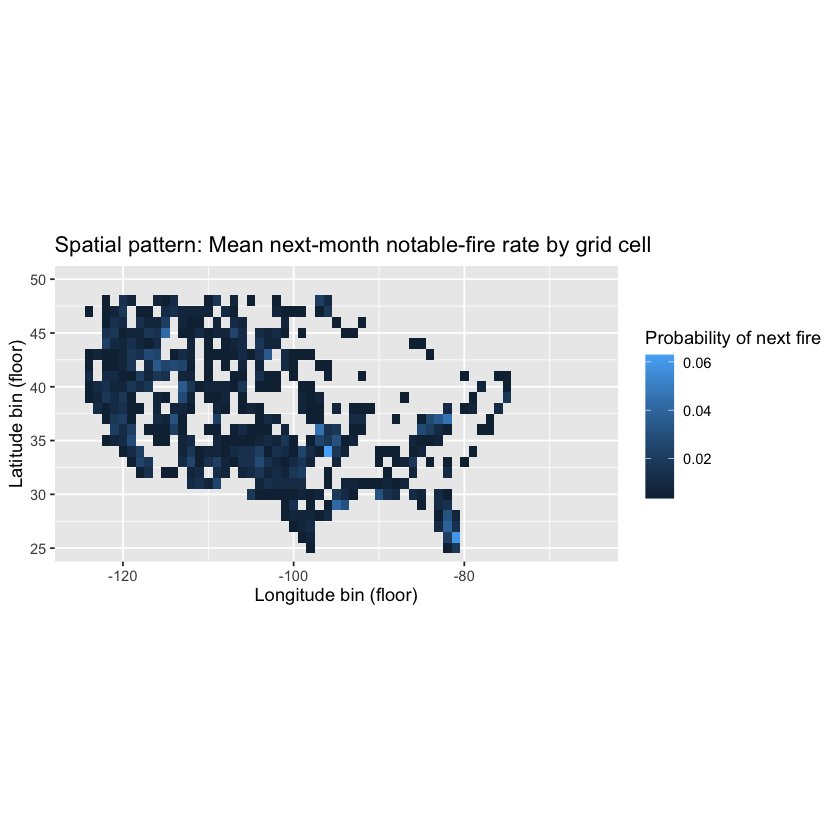

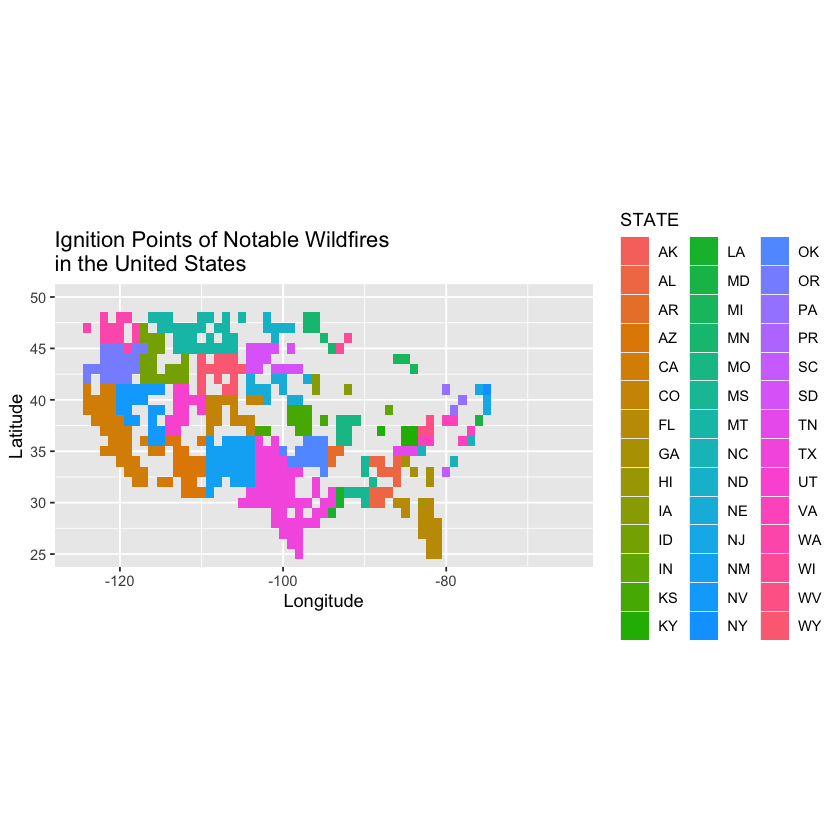

In [355]:
ggplot(eda_spatial, aes(x = lon_bin, y = lat_bin, fill = prob_next_fire)) +
  coord_quickmap(xlim = c(-125, -65), ylim = c(25, 50)) + 
  geom_tile() +
  labs(
    title = "Spatial pattern: Mean next-month notable-fire rate by grid cell",
    x = "Longitude bin (floor)",
    y = "Latitude bin (floor)",
    fill = "Probability of next fire"
  )

ggplot(wildfires_300, aes(x = lon_bin, y = lat_bin, fill = STATE)) +
    coord_quickmap(xlim = c(-125, -65), ylim = c(25, 50)) + 
    geom_tile() +
    labs(title = "Ignition Points of Notable Wildfires\nin the United States",
         x = "Longitude",
         y = "Latitude")

### Temporal EDA

In [267]:
eda_temporal <- panel_new |>
    group_by(month) |>
    summarise(
         prob_next_fire = mean(y_next),
        .groups = "drop")

head(eda_temporal)

month,prob_next_fire
<dbl>,<dbl>
1,0.005329457
2,0.009609173
3,0.010012920
4,0.007428941
5,0.016795866
6,0.018976098


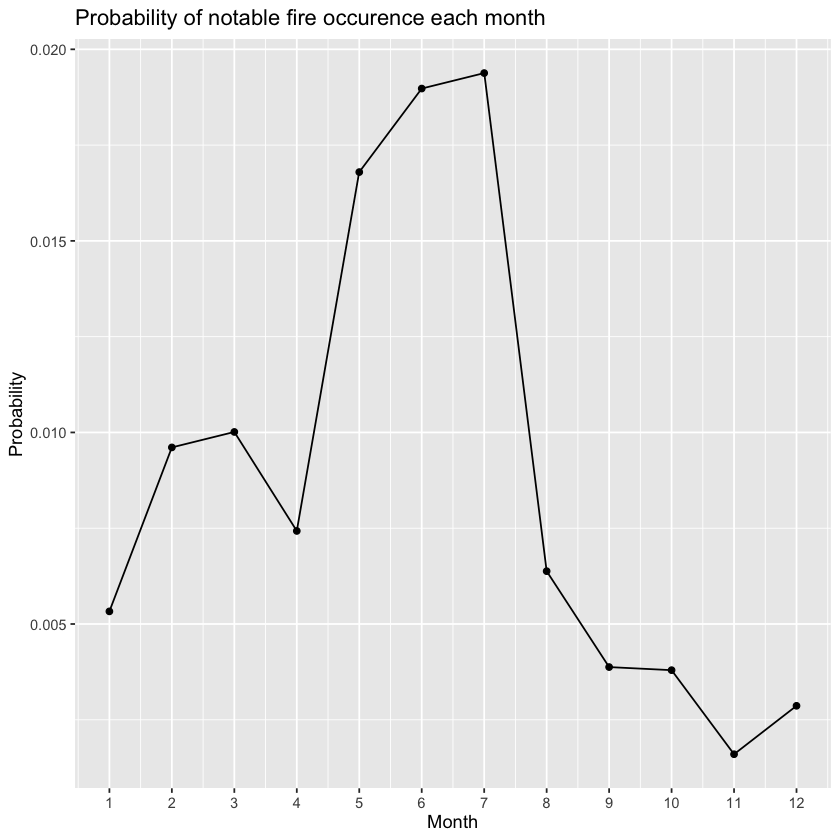

In [268]:
ggplot(eda_temporal, aes(x = month, y = prob_next_fire)) +
    geom_line() + 
    geom_point() + 
    scale_x_continuous(breaks = 1:12) +
    labs(title = "Probability of notable fire occurence each month",
         x = "Month",
         y = "Probability")


MONTH,mean_fire_size
<dbl>,<dbl>
1,1074.972
2,1142.195
3,1277.504
4,5493.661
5,4861.593
6,8566.091


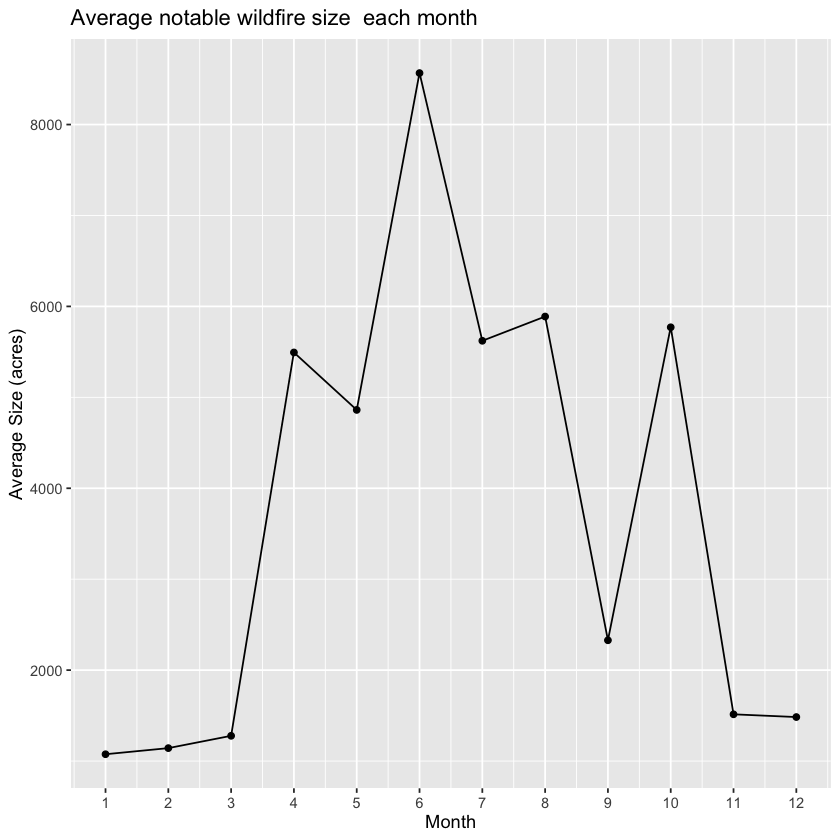

In [269]:
temporal_2 <- wildfires_300 |>
    select(MONTH, FIRE_SIZE)
temporal_2 <- temporal_2 |>
    group_by(MONTH) |>
    summarise(
        mean_fire_size = mean(FIRE_SIZE),
        .groups = "drop")

head(temporal_2)

ggplot(temporal_2, aes(x = MONTH, y = mean_fire_size)) +
    geom_line() + 
    geom_point() + 
    scale_x_continuous(breaks = 1:12) +
    labs(title = "Average notable wildfire size  each month",
         x = "Month",
         y = "Average Size (acres)")



### 3. Modeling

In this section, you will specify and justify the predictive models. You must fit at least **two** models.

1. **Baseline model.** A simple and interpretable model (e.g., logistic regression) that establishes a performance benchmark. Attend discussion session to get code for this baseline model!

2. **Model of your choice.** This is the model that you choose, after careful examination of the dataset. Ideally, your model should outperform the baseline model. 
   
**Minimum required output:** Description of both the baseline model and the model of your choice.


In [274]:
#Setting up data frame for modeling
model_df <- panel_new |>
  mutate(y_next = factor(y_next, levels = c(0, 1))) |>
  select(y_next, lat_bin, lon_bin, state, 
         month_cos, month_sin, year, 
         n_fires, fire_size)

model_df <- as_tibble(model_df)
head(model_df)

y_next,lat_bin,lon_bin,state,month_cos,month_sin,year,n_fires,fire_size
<fct>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,17,-67,PR,8.660254e-01,5.000000e-01,1992,0,0
0,17,-67,PR,5.000000e-01,8.660254e-01,1992,0,0
0,17,-67,PR,6.123234e-17,1.000000e+00,1992,0,0
0,17,-67,PR,-5.000000e-01,8.660254e-01,1992,0,0
0,17,-67,PR,-8.660254e-01,5.000000e-01,1992,0,0
0,17,-67,PR,-1.000000e+00,1.224647e-16,1992,0,0



### 4. Model Fitting and Validation

This section evaluates how well the models fit historical data and how they generalize over time. You need to use a proper validation method that respect the temporal structure. In other words, the model should avoid data leakage such as predicting outcomes in the past using models trained by future data. 

The performance of the models should be evaluated by proper metrics. One required metric is the Area Under the ROC Curve (AUC). If AUC is not fully appropriate for your second model, you may include additional metrics, but AUC must still be reported for both models.


**Minimum required output:** You must include at least one diagnostic plot (e.g., training loss over iterations, cross-validated AUC over time). 

In [173]:
years_sorted <- sort(unique(model_df$year))
min_train_years <- 3

feat_formula <- y_next ~ lat_bin + lon_bin + state + month_cos + month_sin + year +
  n_fires

fold_results <- tibble(
    train_end_year = years_sorted[(min_train_years):(length(years_sorted) - 2)],
    valid_year = years_sorted[(min_train_years + 1):(length(years_sorted) - 1)]) %>%
  mutate(
      # Logistic Regression
      auc_glm = map2_dbl(train_end_year, valid_year, function(tr_end, va_year) {
          train <- model_df %>% filter(year <= tr_end)
          valid <- model_df %>% filter(year == va_year)
          
              fit <- glm(feat_formula, data = train, family = binomial)
              p_hat <- predict(fit, newdata = valid, type = "response")

          roc_obj <- roc(response = valid$y_next, predictor = p_hat, quiet = TRUE)
          as.numeric(auc(roc_obj))
      }),
      
      # Classification Tree
      auc_tree = map2_dbl(train_end_year, valid_year, function(tr_end, va_year) {
          train <- model_df %>% filter(year <= tr_end)
          valid <- model_df %>% filter(year == va_year)
          
              fit <- rpart(factor(y_next) ~ lat_bin + lon_bin + state + month_cos + month_sin + year +
                            n_fires, data = train, method = "class",
                            control = rpart.control(cp = 0.000001))
              p_hat <- predict(fit, newdata = valid, type = "prob")[, "1"]
          
          roc_obj <- roc(response = valid$y_next, predictor = p_hat, quiet = TRUE)
          as.numeric(auc(roc_obj))
        }), 
      
      # Naive Bayes    
      auc_NB = map2_dbl(train_end_year, valid_year, function(tr_end, va_year) {
          train <- model_df %>% filter(year <= tr_end)
          valid <- model_df %>% filter(year == va_year)
          
              fit <- naiveBayes(feat_formula, data = train)
              p_hat <- predict(fit, newdata = valid)
              p_hat <- as.numeric(as.character(p_hat))
          
          roc_obj <- roc(response = valid$y_next, predictor = p_hat, quiet = TRUE)
          as.numeric(auc(roc_obj))    
      }))

fold_results

train_end_year,valid_year,auc_glm,auc_tree,auc_NB
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1994,1995,0.6779766,0.5000000,0.4969121
1995,1996,0.7218072,0.5000000,0.5104847
1996,1997,0.7922604,0.6928989,0.5613666
1997,1998,0.7568157,0.5000000,0.5258916
1998,1999,0.6702197,0.5000000,0.5125467
1999,2000,0.7256549,0.6401827,0.5389019
2000,2001,0.7320698,0.6817910,0.5329640
2001,2002,0.7286275,0.7310028,0.5275065
2002,2003,0.7285496,0.6774965,0.5243110


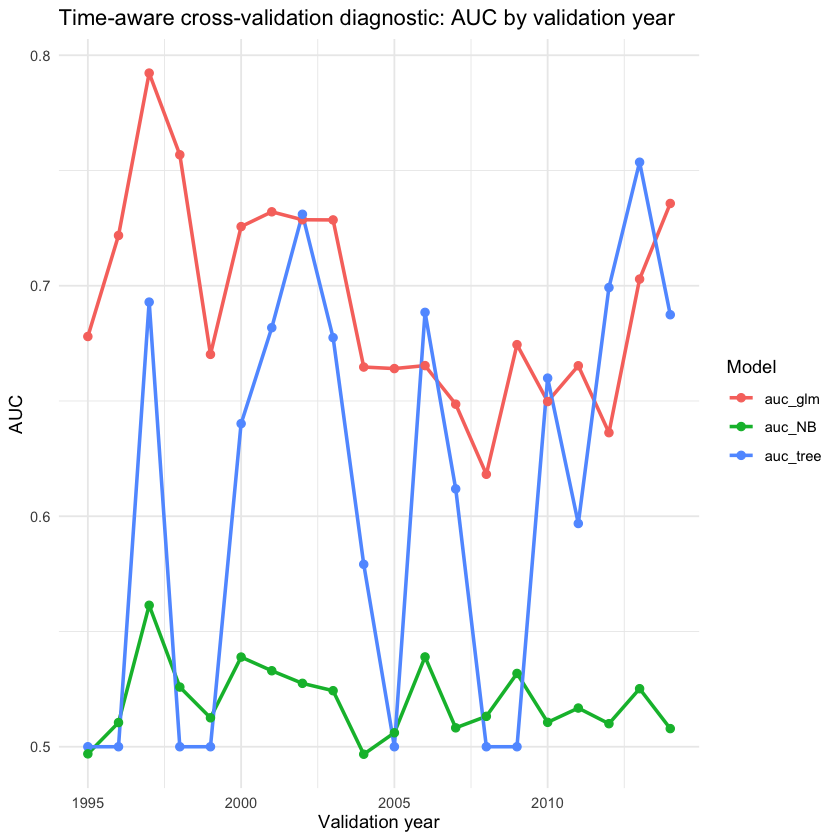

In [165]:
fold_long <- fold_results %>%
  pivot_longer(
    cols = c(auc_glm, auc_tree, auc_NB),
    names_to = "model",
    values_to = "auc"
  )

ggplot(fold_long, aes(x = valid_year, y = auc, color = model)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  labs(
    title = "Time-aware cross-validation diagnostic: AUC by validation year",
    x = "Validation year",
    y = "AUC",
    color = "Model"
  ) + 
  theme_minimal()

#### Tree diagnostics: CV error vs cp

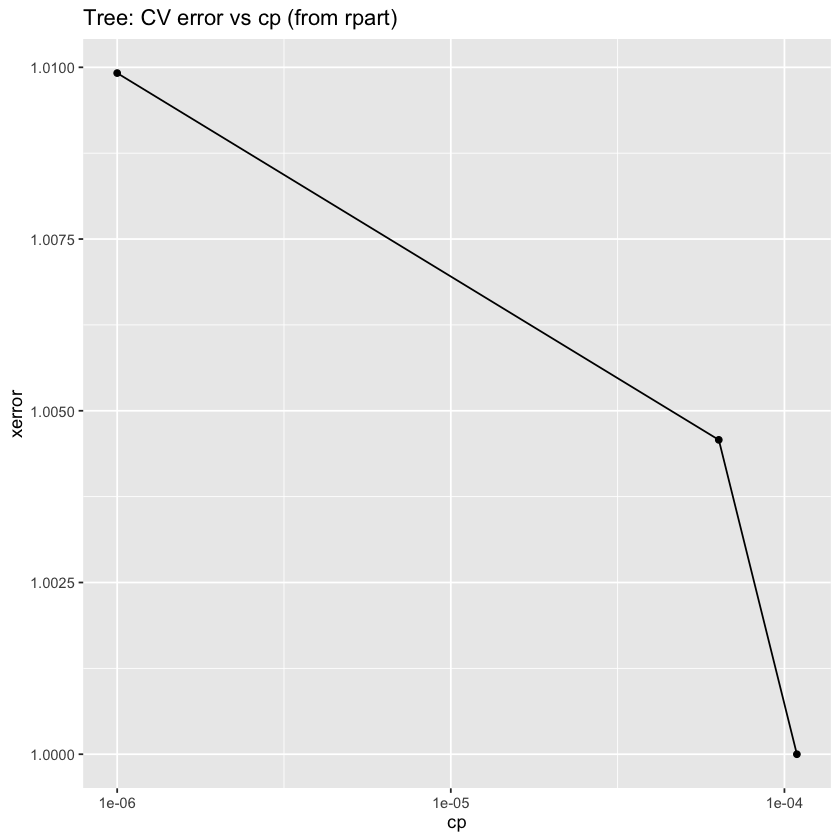

In [285]:
tree_fit <- rpart(factor(y_next) ~ lat_bin + lon_bin + state + month_cos + month_sin + year +
                n_fires, data = model_df, method = "class",
                control = rpart.control(cp = 0.000001))

cp_tbl <- as_tibble(tree_fit$cptable)

ggplot(cp_tbl, aes(CP, xerror)) +
  geom_line() + geom_point() +
  scale_x_log10() +
  labs(title = "Tree: CV error vs cp (from rpart)", x = "cp", y = "xerror")

#### Naive Bayes diagnostis: Confusion Matrix

In [336]:
NB_fit <- naiveBayes(y_next ~ lat_bin + lon_bin + state + month_cos + month_sin + year + n_fires, data = model_df)
pred <- predict(NB_fit, newdata = model_df)

cm <- table(model_df$y_next, pred)
confusionMatrix(cm)

Confusion Matrix and Statistics

   pred
         0      1
  0 145020   1245
  1   1245     66
                                          
               Accuracy : 0.9831          
                 95% CI : (0.9825, 0.9838)
    No Information Rate : 0.9911          
    P-Value [Acc > NIR] : 1               
                                          
                  Kappa : 0.0418          
                                          
 Mcnemar's Test P-Value : 1               
                                          
            Sensitivity : 0.99149         
            Specificity : 0.05034         
         Pos Pred Value : 0.99149         
         Neg Pred Value : 0.05034         
             Prevalence : 0.99112         
         Detection Rate : 0.98268         
   Detection Prevalence : 0.99112         
      Balanced Accuracy : 0.52092         
                                          
       'Positive' Class : 0               
                                          


### 5. Summary

This section summarizes the main findings and contributions of your project. You should summarize the key insights obtained from the exploratory data analysis and explain what your predictive model is able to capture. The discussion should be written for a general audience, emphasizing interpretation and practical understanding rather than technical detail.

**Minimum required output:** Summary of EDA and model performance. 

#### Data preprocessing

- 

#### 